In [55]:
from dsc80_utils import *
import lec16_util as util

# Lecture 16 – Hyperparameters, Cross-Validation, and Decision Trees

## DSC 80, Fall 2025

### Announcements 📣

- Final Project Checkpoint 2 is *not* due Thursday, but instead due **Tuesday, Dec. 2**
- Lab 9 is due on ***optional*** and ***ungraded***.
    - You still might want to do it, since it covers topics on Exam 02.

### Agenda 📆

- Hyperparameters.
- Train/test splits.
- Cross-validation.
- Decision trees.

# Model Complexity

- Last time, we took a look at the following data set:

In [56]:
np.random.seed(23) # For reproducibility.

def sample_from_pop(n=100):
    x = np.linspace(-2, 3, n)
    y = x ** 3 + (np.random.normal(0, 3, size=n))
    return pd.DataFrame({'x': x, 'y': y})

past_data = sample_from_pop()
future_data = sample_from_pop()

In [57]:
px.scatter(past_data, x='x', y='y', title='Past Data')

- We trained three polynomial regression models of increasing **complexity**:
    - Degree 1 polynomial $H(x) = w_0 + w_1 x$ (straight line)
    - Degree 3 polynomial $H(x) = w_0 + w_1 x + w_2 x^2 + w_3 x^3$ (cubic)
    - Degree 25 polynomial $H(x) = w_0 + w_1 x + w_2 x^2 + \ldots + w_{24} x^{24} + w_{25}x^{25}$ (a very wiggly curve)

In [58]:
fig = util.train_and_plot(train_sample=past_data, test_sample=past_data, degs=[1, 3, 25], data_name='Past Data')
fig.update_layout(title='Trained on Past Data, Performance on Past Data')

- "Complex" models are more "flexible", so they are able to fit the training data better.
    - In theory, a degree 99 polynomial would be able to fit this data *exactly*; in practice, you run into numerical issues training such a model.
- RMSE is a measure of how well the line fits the data.
- So as the model becomes more "complex", the RMSE on the past data goes down.
    - This is a mathematical certainty!

## Future, Unseen Data

- Now imagine we get access to a new, unseen data and use our already-trained models to make predictions.
- How well do they do?

In [59]:
fig = util.train_and_plot(train_sample=past_data, test_sample=future_data, degs=[1, 3, 25], data_name='Future Data')
fig.update_layout(title='Trained on Past Data, Performance on Unseen, Future Data')

- The most complex model (degree 25) is no longer the best!
- In short, it is "overfit" to the past data, and does not generalize well to new, unseen data.
- Meanwhile, the degree 1 polynomial is "underfit".

## Generalization

- When building a model, we typically care most about its performance on future, unseen data.
    - That is, we care about **test error** more than *training error*.
- A model that does well on future, unseen data is said to "generalize well".
- **Important**: the model with the lowest training error does not always have the lowest test error.
    - In fact, it usually doesn't!
    - If the training error is too low, it can be a sign of **overfitting**.

## Complexity and Generalization

- The complexity of our model determines how well it will generalize.
    - If the model is *too* complex, it will *overfit* the training data and will not generalize well.
    - If the model is *not complex enough*, it will *underfit* the training data and will not generalize well.
    - We need the complexity of our model to be "just right".
- How do we determine how complex our model should be?

## Hyperparameters

- We have a choice to make: the degree of polynomial to use in our model.
- The polynomial degree is an example of a **hyperparameter**.
- In general, a hyperparameter is a knob you can turn to adjust the complexity of the model.
    - In poynomial regression: degree of polynomial.
    - In decision trees: max depth of the tree, max number of nodes, etc.
    - In $k$-nearest neighbors, $k$.
    - etc.
- **Question**: How do we choose the hyperparameter that will lead to the best performance in the future?
    - This is another way of asking: "How do we determine how complex our model should be?"

## But wait...

- We want to choose the hyperparameter (polynomial degree) so that we get the best performance on future, unseen data.
- How do we do this if (by definition) *we don't have* the future data?

## The idea: train / test splits

- Split the data you have into two pieces:
    - A **training set** used to train the data. We imagine this data to be "from the past".
    - A **test set** that we imagine to be data from the future.

- Idea:
    1. Come up with a **list** of hyperparameters to try.
    2. For each choice of hyperparameter:
       - 1. train the model on the training set
       - 2. evaluate its performance on the test set.
    3. Pick the hyperparameter with the best performance on the test set.

- Why does this work?
    - We typically assume that future data will look like past data, but slightly different due to randomness.
    - In a random split of data, the test set looks like the train set without being the same.

### Training error vs. test error

- Let's try this strategy on our earlier example.
- We'll try to fit a polynomial model on the dataset; we'll choose the polynomial's degree from the list [1, 2, ..., 25].
- Now, we are given one dataset:

In [60]:
data = sample_from_pop()

In [61]:
px.scatter(data, x='x', y='y', title='Data')

First, we perform a train-test split.

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X = data[['x']]
y = data['y']

# randomly splits the data into 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=100)

In [64]:
px.scatter(x=X_train['x'], y=y_train, title='Training Data')

In [65]:
px.scatter(x=X_test['x'], y=y_test, title='Test Data')

### Polynomial degree vs. train/test error

Now, we'll create models with degree-1 through degree-25 polynomial features and compute their train and test errors.

In [66]:
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, Binarizer
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LinearRegression

In [67]:
train_errs = []
test_errs = []

for d in range(1, 26):
    pl = make_pipeline(PolynomialFeatures(d), LinearRegression())
    pl.fit(X_train, y_train)
    train_errs.append(root_mean_squared_error(y_train, pl.predict(X_train)))
    test_errs.append(root_mean_squared_error(y_test, pl.predict(X_test)))

errs = pd.DataFrame({'Train Error': train_errs, 'Test Error': test_errs})

Let's look at the plots of training error vs. degree and test error vs. degree.

In [68]:
fig = px.line(errs)
fig.update_layout(showlegend=True, xaxis_title='Polynomial Degree', yaxis_title='RMSE')

- Training error appears to decrease as polynomial degree increases.

- Test error appears to decrease until a "valley", and then increases again.

- Here, we'd choose a degree of 3, since that degree has the **lowest test error**.

### Training error vs. test error

The pattern we saw in the previous example is (often) true more generally.
- Though not always, see [double descent](https://en.wikipedia.org/wiki/Double_descent)

<center><img src='imgs/tt-errors.png' width=50%></center>

We pick the hyperparameter(s) at the "valley" of test error.

### Conducting train-test splits

- Recall, <span style='color: blue'><b>training data</b></span> is used to fit our model, and <span style='color: orange'><b>test data</b></span> is used to evaluate our model.

<center><img src='imgs/train-test-first.png' width=40%></center>

- **Question**: _How_ should we split?
    - `sklearn`'s `train_test_split` splits **randomly**, which usually works well.
    - Randomization is important! If your data set is sorted, and you used the first 3/4 for training data without randomizing, the test data would look very different from the train data.
    - However, if there is some element of **time** in the training data (say, when predicting the future price of a stock), a better split is "past" and "future".

- **Question**: How _large_ should the split be, e.g. 90%-10% vs. 75%-25%?
    - There's a tradeoff – a larger training set should lead to a "better" model, while a larger test set should lead to a better estimate of our model's ability to generalize.
    - There's no "right" choice, but we usually choose between 10% to 25% for the test set.

## Estimators of the generalization error

- Imagine you had a way of getting unlimited future data.
- You could use this to compute the *generalization error*: your model's RMSE on an infinite future data set.
- You want the model with the smallest generalization error, but the generalization error is impossible to know.
- Both the **train error** and the **test error** are *estimates* of the *generalization error*.
    - The *train error* is usually a **bad estimate**, because it's biased low.
        - The train error is like your score on a practice exam, after you already used the practice exam to study.
    - The *test error* is a *much better* estimate of the generalization error, but is still biased low because we pick the hyperparameter that minimizes it.
- Note that training error **tends** to underestimate test and generalization error, but it doesn't have to – i.e., it is possible for test error to be lower than training error (say, if the test set is "easier" to predict than the training set).

### But wait...

- There is an issue with this simple train/test approach: the test error is still biased low.
    - You picked the hyperparameter that gave the smallest test error, so you should expect the actual generalization error to be slightly higher.
- This means two things:
  - The test error is still optimistic, and doesn't give you a great sense of how well your model will do on future data.
  - The hyperparameter you chose was "tailored" to that specific test set; a different test set might have given a different hyperparameter.
      - In a sense, you may have overfit your hyperparameter to this specific test set.

## Takeaway

- For your test error to be a great estimate of the generalization error, you can't "peek" at it at all while building the model.
    - Can't use it to choose hyperparameters.
    - Certainly can't use it to pick parameters!
- Leave the test set aside, put it in under lock and key, don't touch it until you're ready to report your model's performance.
- A simple train/test split doesn't do this, but a more complicated approach does...

## Cross-validation

### Idea: A single validation set

<center><img src='imgs/train-test-val.png' width=40%></center>

1. Split the data into three sets: <span style='color: blue'><b>training</b></span>, <span style='color: green'><b>validation</b></span>, and <span style='color: orange'><b>test</b></span>.

2. For each hyperparameter choice, <span style='color: blue'><b>train</b></span> the model only on the <span style='color: blue'><b>training set</b></span>, and <span style='color: green'><b>evaluate</b></span> the model's performance on the <span style='color: green'><b>validation set</b></span>.

3. Find the hyperparameter with the best <span style='color: green'><b>validation</b></span> performance.

4. Retrain the final model on the <span style='color: blue'><b>training</b></span> and <span style='color: green'><b>validation</b></span> sets, and report its performance on the <span style='color: orange'><b>test set</b></span>.

- **Good**: test error is only computed after model is completely built, so it's a better esimate of generalization error.
- **Bad**: This strategy is too dependent on the <span style='color: green'><b>validation</b></span> set, which may be small and/or not a representative sample of the data. It's also wasteful of data. **We're not going to do this.** ❌

### A better idea: $k$-fold cross-validation

Instead of relying on a single <span style='color: green'><b>validation</b></span> set, we can create $k$ <span style='color: green'><b>validation</b></span> sets, where $k$ is some positive integer (5 in the example below).

<center><img src='imgs/k-fold.png' width=40%></center>

Since each data point is used for <span style='color: blue'><b>training</b></span> $k-1$ times and <span style='color: green'><b>validation</b></span> once, the (averaged) <span style='color: green'><b>validation</b></span> performance should be a good metric of a model's ability to generalize to unseen data.

$k$-fold cross-validation (or simply "cross-validation") is **the** technique we will use for finding hyperparameters, or more generally, for choosing between different possible models. **It's what you should use in your Final Project!** ✅

### $k$-fold cross-validation

1. Randomly split the entire dataset into **outer train** and **outer test** using `train_test_split`. Put the test set under lock and key, don't touch it until ready to report overall performance.
2. Shuffle your **outer train** set and slice it into $k$ disjoint "folds".
3. For each choice of hyperparameter:
    1. For $i$ in range(k):
        1. Let slice $i$ be the **validation** set.
        2. Merge other slices into an **inner train** set.
        3. Train your model using the hyperparameter.
        4. Evaluate on the validation set to get $\text{score}_i$
    2. Compute the average of the scores, $\text{score}_1, \ldots, \text{score}_k$. This gives one summary score for that choice of hyperparameter.
4. Choose the hyperparameter that had the best validation score.
5. Combine all the folds back into one **outer train** set, train your model on it using the selected hyperparameter.
6. Evaluate your model on the **outer test** set and report the final score.

Let's do 5-fold cross-validation manually in Python.

In [69]:
np.random.seed(13)

data = sample_from_pop()

# we'll do 5-fold cross-validation
k = 5

# our hyperparameters: polynomial orders from 1 to 25
hyperparameters = list(range(1, 26))

# step 1) randomly split into outer train, outer test
outer_train_x, outer_test_x, outer_train_y, outer_test_y = train_test_split(data['x'], data['y'])

# step 2) make k slices, or "folds". We'll do this manually, but 
# sklearn.model_selection.KFold is more convenient. Note that `outer_train` has 75
# elements.
folds = [
    list(range(0, 15)),
    list(range(15, 30)),
    list(range(30, 45)),
    list(range(45, 60)),
    list(range(60, 75))
]

# step 3) perform k-fold cross-val
hyperparameter_scores = {}
for hyperparameter in hyperparameters:
    print(f"Using hyperparameter {hyperparameter}...")
    
    scores_in_each_fold = []
    
    for i in range(k):

        # step 3.A.a) let fold i be the validation set
        validation_indices = folds[i]
        validation_x = outer_train_x.iloc[validation_indices].to_frame()
        validation_y = outer_train_y.iloc[validation_indices]

        # step 3.A.b) combine all of the other folds into one inner train set
        inner_train_indices = np.array([folds[j] for j in range(k) if j != i]).flatten()
        inner_train_x = outer_train_x.iloc[inner_train_indices].to_frame()
        inner_train_y = outer_train_y.iloc[inner_train_indices]
        
        print(f"\tValidating on fold {i}, training on folds {list(set(range(5)) - {i})}", end='')
        
        # step 3.A.c) train the model using the hyperparameter
        pl = make_pipeline(PolynomialFeatures(hyperparameter), LinearRegression())
        pl.fit(inner_train_x, inner_train_y)

        # step 3.A.d) evaluate on validation set to get i-th score
        score = pl.score(validation_x, validation_y)
        scores_in_each_fold.append(score)

        print(f" Score: {score:0.2f}")

    # step #3.B) average the scores to get one score for the hyperparameter
    average_score = np.mean(scores_in_each_fold)
    hyperparameter_scores[hyperparameter] = average_score

    print(f"\tAverage score: {average_score:0.2f}")

# step 4) choose the hyperparameter that has the best score
best_hyperparameter = max(hyperparameter_scores, key=lambda k: hyperparameter_scores[k])

print("Best hyperparameter:", best_hyperparameter)

# step 5) combine all folds back into one outer training set and train using this hyperparameter
pl = make_pipeline(PolynomialFeatures(best_hyperparameter), LinearRegression())
pl.fit(outer_train_x.to_frame(), outer_train_y)

# step 6) report the final score
pl.score(outer_test_x.to_frame(), outer_test_y)

Using hyperparameter 1...
	Validating on fold 0, training on folds [1, 2, 3, 4] Score: 0.27
	Validating on fold 1, training on folds [0, 2, 3, 4] Score: 0.70
	Validating on fold 2, training on folds [0, 1, 3, 4] Score: 0.59
	Validating on fold 3, training on folds [0, 1, 2, 4] Score: 0.65
	Validating on fold 4, training on folds [0, 1, 2, 3] Score: 0.64
	Average score: 0.57
Using hyperparameter 2...
	Validating on fold 0, training on folds [1, 2, 3, 4] Score: 0.55
	Validating on fold 1, training on folds [0, 2, 3, 4] Score: 0.90
	Validating on fold 2, training on folds [0, 1, 3, 4] Score: 0.70
	Validating on fold 3, training on folds [0, 1, 2, 4] Score: 0.52
	Validating on fold 4, training on folds [0, 1, 2, 3] Score: 0.84
	Average score: 0.70
Using hyperparameter 3...
	Validating on fold 0, training on folds [1, 2, 3, 4] Score: 0.79
	Validating on fold 1, training on folds [0, 2, 3, 4] Score: 0.88
	Validating on fold 2, training on folds [0, 1, 3, 4] Score: 0.83
	Validating on fold 3,

0.8262982357877007

### $k$-fold cross-validation in `sklearn`

Of course, `sklearn` makes this much easier. The `cross_val_score` function in `sklearn` implements $k$-fold cross-validation for us! 

```py
cross_val_score(estimator, X_train, y_train, cv)
```

Specifically, it takes in:
- A `Pipeline` or estimator **that has not already been `fit`**.
- Training data.
- A value of $k$ (through the `cv` argument).
- (Optionally) A `scoring` metric.

and performs $k$-fold cross-validation, returning the values of the scoring metric on each fold.

In [70]:
from sklearn.model_selection import cross_val_score

### $k$-fold cross-validation in `sklearn`

- Let's perform $k$-fold cross validation in order to help us pick a degree for polynomial regression from the list [1, 2, ..., 25].

- We'll use $k=5$ since it's a common choice (and the default in `sklearn`).

In [71]:
hyperparameters = list(range(1, 26))

outer_train_x, outer_test_x, outer_train_y, outer_test_y = train_test_split(data['x'], data['y'])

hyperparameter_scores = {}
scores_in_each_fold = {}
for hyperparameter in hyperparameters:
    pl = make_pipeline(PolynomialFeatures(hyperparameter), LinearRegression())
    scores_in_each_fold[hyperparameter] = cross_val_score(pl, outer_train_x.to_frame(), outer_train_y, cv=5)
    average_score = scores_in_each_fold[hyperparameter].mean()
    hyperparameter_scores[hyperparameter] = average_score

best_hyperparameter = pd.Series(hyperparameter_scores).idxmax()
best_hyperparameter

np.int64(3)

To train our final model, we'll use the entire outer train set and the best choice of hyperparameter:

In [72]:
pl = make_pipeline(PolynomialFeatures(best_hyperparameter), LinearRegression())
pl.fit(outer_train_x.to_frame(), outer_train_y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=np.int64(3))),
                ('linearregression', LinearRegression())])

We'll evaluate it on the test set (which we haven't touched until now):

In [73]:
pl.score(outer_test_x.to_frame(), outer_test_y)

0.8753405654555702

Next class, we'll look at how to implement this procedure without needing to `for`-loop over values of `d`.

### $k$-fold cross-validation in `sklearn`

Note that for each choice of degree (our hyperparameter), we have **five** scores, one for each "fold" of the data. This means that in total, $5 \cdot 25 = 125$ models were trained/fit to data!

In [74]:
scores_df = pd.DataFrame(scores_in_each_fold)
scores_df.index = [f'Fold {i+1}' for i in scores_df.index]
scores_df.index.name = 'Validation Fold'
scores_df.columns = [f'Deg {p}' for p in scores_df.columns]
scores_df

,Deg 1,Deg 2,Deg 3,Deg 4,...,Deg 22,Deg 23,Deg 24,Deg 25
Validation Fold,,,,,,,,,
Fold 1,0.70,0.82,0.91,0.91,...,-137.66,-9927.74,-41671.60,-203834.05
Fold 2,-1.47,-0.65,-0.02,-0.06,...,-14.33,-47.33,-4.52,-499.02
Fold 3,0.72,0.85,0.88,0.88,...,0.90,0.90,0.88,0.44
Fold 4,0.69,0.86,0.94,0.94,...,-3.57,-5.09,-0.37,-2319.38
Fold 5,0.50,0.58,0.69,0.69,...,0.61,0.62,0.62,-0.94


We should choose the degree with the highest **average** validation $r^2$.

In [75]:
scores_df.mean().idxmax()

'Deg 3'

Note that if we didn't perform $k$-fold cross-validation, but instead just used a single validation set, we may have ended up with a different result:

In [76]:
scores_df.idxmax(axis=1)

Validation Fold
Fold 1     Deg 6
Fold 2     Deg 3
Fold 3    Deg 22
Fold 4    Deg 17
Fold 5     Deg 3
dtype: object

### Another example: Tips

- Another way to control a model's complexity is to add/remove features.
    - The more features, the more complex the model. 
- We can also use $k$-fold cross-validation to determine which subset of features to use in a linear model that predicts tips by making one pipeline for each subset of features we want to evaluate.

In [77]:
# make_column_transformer is a shortcut for the ColumnTransformer class
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

As we should always do, we'll perform a train-test split on `tips` and will only use the training data for cross-validation.

In [78]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [79]:
X = tips.drop('tip', axis=1)
y = tips['tip']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [80]:
# A dictionary that maps names to Pipeline objects.
select = FunctionTransformer(lambda x: x)
pipes = {
    'total_bill only': make_pipeline(
        make_column_transformer( (select, ['total_bill']) ),
        LinearRegression(),
    ),
    'total_bill + size': make_pipeline(
        make_column_transformer( (select, ['total_bill', 'size']) ),
        LinearRegression(),
    ),
    'total_bill + size + OHE smoker': make_pipeline(
        make_column_transformer(
            (select, ['total_bill', 'size']),
            (OneHotEncoder(drop='first'), ['smoker']),
        ),
        LinearRegression(),
    ),
    'total_bill + size + OHE all': make_pipeline(
        make_column_transformer(
            (select, ['total_bill', 'size']),
            (OneHotEncoder(drop='first'), ['smoker', 'sex', 'time', 'day']),
        ),
        LinearRegression(),
    ),
}

In [81]:
pipe_df = pd.DataFrame()

for pipe in pipes:
    errs = cross_val_score(pipes[pipe], X_train, y_train,
                           cv=5, scoring='neg_root_mean_squared_error')
    pipe_df[pipe] = -errs
    
pipe_df.index = [f'Fold {i}' for i in range(1, 6)]
pipe_df.index.name = 'Validation Fold'

In [82]:
pipe_df

,total_bill only,total_bill + size,total_bill + size + OHE smoker,total_bill + size + OHE all
Validation Fold,,,,
Fold 1,1.32,1.27,1.27,1.29
Fold 2,0.95,0.92,0.93,0.93
Fold 3,0.77,0.86,0.86,0.87
Fold 4,0.85,0.84,0.84,0.86
Fold 5,1.10,1.07,1.07,1.08


In [83]:
pipe_df.mean()

total_bill only                   1.00
total_bill + size                 0.99
total_bill + size + OHE smoker    0.99
total_bill + size + OHE all       1.01
dtype: float64

In [84]:
pipe_df.mean().idxmin()

'total_bill + size + OHE smoker'

Even though the third model has the lowest average validation RMSE, its average validation RMSE is very close to that of the other, simpler models, and as a result we'd likely use the simplest model in practice.

<div class="alert alert-warning">
    <h3>Question 🤔</h3>

</div>

- Suppose you have a training dataset with 1000 rows.
- You want to decide between 20 hyperparameters for a particular model.
- To do so, you perform 10-fold cross-validation.
- **How many times is the first row in the training dataset (`X.iloc[0]`) used for training a model?**


### Summary: Generalization

1. Split the data into two sets: <span style='color: blue'><b>training</b></span> and <span style='color: orange'><b>test</b></span>.

2. Use only the <span style='color: blue'><b>training</b></span> data when designing, training, and tuning the model.
    - Use <span style='color: green'><b>$k$-fold cross-validation</b></span> to choose hyperparameters and estimate the model's ability to generalize.
    - Do not ❌ look at the <span style='color: orange'><b>test</b></span> data in this step!

3. Commit to your final model and train it using the entire <span style='color: blue'><b>training</b></span> set.

4. Test the data using the <span style='color: orange'><b>test</b></span> data. If the performance (e.g. RMSE) is not acceptable, return to step 2.

5. Finally, train on **all available data** and ship the model to production! 🛳

🚨 This is the process you should **always** use! 🚨 

## Decision trees 🌲

<center><img src='imgs/ml-taxonomy.svg' width=50%></center>

Decision trees can be used for both regression and classification. We'll start by using them for **classification**.

### Example: Should I get groceries?

Decision trees make classifications by answering a series of yes/no questions.

**Should I go to Trader Joe's to buy groceries today?**

<center><img src='imgs/dtree-basic.svg' width=400></center>

Internal **nodes** of trees involve questions; leaf nodes make predictions $H(x)$.

<center><img src='imgs/dtree-basic-plot.svg' width=400></center>

### Example: Predicting diabetes

In [85]:
diabetes = pd.read_csv(Path('data') / 'diabetes.csv')
display_df(diabetes, cols=9)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.63,50,1
1,1,85,66,29,0,26.6,0.35,31,0
2,8,183,64,0,0,23.3,0.67,32,1
...,...,...,...,...,...,...,...,...,...
765,5,121,72,23,112,26.2,0.24,30,0
766,1,126,60,0,0,30.1,0.35,47,1
767,1,93,70,31,0,30.4,0.32,23,0


In [86]:
# 0 means no diabetes, 1 means yes diabetes.
diabetes['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

- `'Glucose'` is measured in mg/dL (milligrams per deciliter).

- `'BMI'` is calculated as $\text{BMI} = \frac{\text{weight (kg)}}{\left[ \text{height (m)} \right]^2}$.

- Let's use `'Glucose'` and `'BMI'` to predict whether or not a patient has diabetes (`'Outcome'`).

### Exploring the dataset

First, a train-test split:

In [87]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = (
    train_test_split(diabetes[['Glucose', 'BMI']], diabetes['Outcome'], random_state=1)
)

<span style='color: orange'><b>Class 0 (orange) is "no diabetes"</b></span> and <span style='color: blue'><b>class 1 (blue) is "diabetes"</b></span>.

In [88]:
fig = (
    X_train.assign(Outcome=y_train.astype(str))
            .plot(kind='scatter', x='Glucose', y='BMI', color='Outcome', 
                  color_discrete_map={'0': 'orange', '1': 'blue'},
                  title='Relationship between Glucose, BMI, and Diabetes')
)
fig

### Building a decision tree

Let's build a decision tree and interpret the results.

The relevant class is `DecisionTreeClassifier`, from `sklearn.tree`.

In [89]:
from sklearn.tree import DecisionTreeClassifier

Note that we `fit` it the same way we `fit` earlier estimators.

_You may wonder what `max_depth` and `criterion` do – more on this soon!_

In [90]:
dt = DecisionTreeClassifier(max_depth=2, criterion='entropy')

In [91]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2)

### Visualizing decision trees

Our fit decision tree is like a "flowchart", made up of a series of questions.

As before, <span style='color: orange'><b>orange is "no diabetes"</b></span> and <span style='color: blue'><b>blue  is "diabetes"</b></span>.

In [92]:
from sklearn.tree import plot_tree

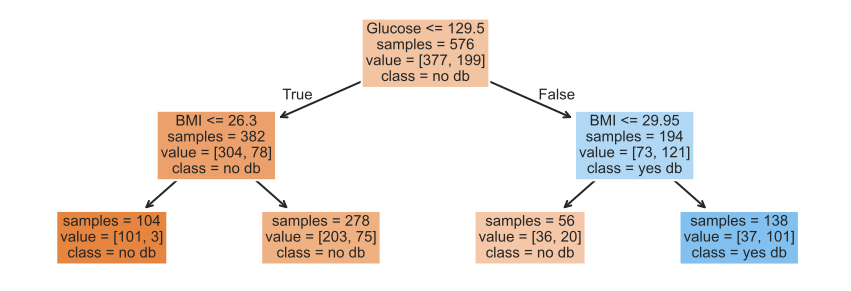

In [93]:
plt.figure(figsize=(15, 5))
plot_tree(dt, feature_names=X_train.columns, class_names=['no db', 'yes db'], 
          filled=True, fontsize=15, impurity=False);

- To **classify a new data point**, we start at the top and answer the first question (i.e. "Glucose <= 129.5").

- If the answer is "**Yes**", we move to the **left** branch, otherwise we move to the right branch.

- We repeat this process until we end up at a leaf node, at which point we predict the most common class in that node.
    - Note that each node has a `value` attribute, which describes the number of **training** individuals of each class that fell in that node.

In [40]:
# Note that the left node at depth 2 has a `value` of [304, 78].
y_train[X_train.query('Glucose <= 129.5').index].value_counts()

Outcome
0    304
1     78
Name: count, dtype: int64

### Evaluating classifiers

The most common evaluation metric in classification is **accuracy**:

$$\text{accuracy} = \frac{\text{\# data points classified correctly}}{\text{\# data points}}$$

In [41]:
(dt.predict(X_train) == y_train).mean()

np.float64(0.765625)

The `score` method of a classifier computes accuracy by default (just like the `score` method of a regressor computes $R^2$ by default). We want our classifiers to have **high accuracy**.

In [42]:
# Training accuracy – same number as above
dt.score(X_train, y_train)

0.765625

In [43]:
# Testing accuracy
dt.score(X_test, y_test)

0.7760416666666666

### Reflection

- Decision trees are easily interpretable: it is clear _how_ they make their predictions.

- They work with categorical data without needing to use one hot encoding.

- They also can be used in multi-class classification problems, e.g. when there are more than 2 possible outcomes.

- The _decision boundary_ of a decision tree can be arbitrarily complicated.

- **How are decision trees trained?**

### How are decision trees trained?

Pseudocode:

```python
def make_tree(X, y):
    if all points in y have the same label C:
        return Leaf(C)
    f = best splitting feature # e.g. Glucose or BMI
    v = best splitting value   # e.g. 129.5
    
    X_left, y_left   = X, y where (X[f] <= v)
    X_right, y_right = X, y where (X[f] > v)
    
    left  = make_tree(X_left, y_left)
    right = make_tree(X_right, y_right)
    
    return Node(f, v, left, right)
    
make_tree(X_train, y_train)
```

### How do we measure the quality of a split?

Our pseudocode for training a decision tree relies on finding the best way to "split" a node – that is, **the best question to ask** to help us narrow down which class to predict.

**Intuition**: Suppose the distribution within a node looks like this (colors represent classes):

<center>🟠🟠🟠🟠🟠🟠🔵🔵🔵🔵🔵🔵🔵</center>

Split A:
- "Yes": 🟠🟠🟠🔵🔵🔵
- "No": 🟠🟠🟠🔵🔵🔵🔵

Split B:
- "Yes": 🔵🔵🔵🔵🔵🔵
- "No": 🔵🟠🟠🟠🟠🟠🟠

**Which split is "better"?**

Split B, because there is "less uncertainty" in the resulting nodes in Split B than there is in Split A. Let's try and quantify this!

### Entropy

- For each class $C$ within a node, define $p_C$ as the proportion of points with that class.
    - For example, the two classes may be "yes diabetes" and "no diabetes".

- The **surprise** of drawing a point from the node at random and having it be class $C$ is:

$$
- \log_2 p_C
$$

- The **entropy** of a node is the average surprise over all classes:

\begin{align}
\text{entropy} &= - \sum_C p_C \log_2 p_C
\end{align}

- The entropy of 🟠🟠🟠🟠🟠🟠🟠🟠 is $ -1 \log_2(1) = 0 $.

- The entropy of 🟠🟠🟠🟠🔵🔵🔵🔵 is $ -0.5 \log_2(0.5) - 0.5 \log_2(0.5) = 1$.

- The entropy of 🟠🔵🟢🟡🟣 is $ - \log_2 \frac{1}{5} = \log_2(5) $
    - In general, if a node has $n$ points, all with different labels, the entropy of the node is $ \log_2(n) $.

### Example entropy calculation

Suppose we have:

<center>🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🔵🔵🔵🔵🔵🔵</center>

Split A:
- "Yes": 🟠🟠🟠🟠🟠🟠🔵
- "No": 🟠🟠🟠🟠🟠🟠🔵🔵🔵🔵🔵

Split B:
- "Yes": 🟠🟠🟠🟠🟠🟠🔵🔵🔵
- "No": 🟠🟠🟠🟠🟠🟠🔵🔵🔵

We choose the split that has the lowest **weighted entropy**, that is:

$$\text{entropy of split} = \frac{\# \text{Yes}}{\# \text{Yes} + \# \text{No}} \cdot \text{entropy(Yes)} + \frac{\# \text{No}}{\# \text{Yes} + \# \text{No}} \cdot \text{entropy(No)}$$

In [44]:
def entropy(node):
    props = pd.Series(list(node)).value_counts(normalize=True)
    return -sum(props * np.log2(props))

In [45]:
def weighted_entropy(yes_node, no_node):
    yes_entropy = entropy(yes_node)
    no_entropy = entropy(no_node)
    yes_weight = len(yes_node) / (len(yes_node) + len(no_node))
    return yes_weight * yes_entropy + (1 - yes_weight) * no_entropy

In [46]:
# Split A:
weighted_entropy("🟠🟠🟠🟠🟠🟠🔵", "🟠🟠🟠🟠🟠🟠🔵🔵🔵🔵🔵")

0.8375578764623786

In [47]:
# Split B:
weighted_entropy("🟠🟠🟠🟠🟠🟠🔵🔵🔵", "🟠🟠🟠🟠🟠🟠🔵🔵🔵")

0.9182958340544896

Split A has the lower weighted entropy, so we'll use it.

### Understanding entropy

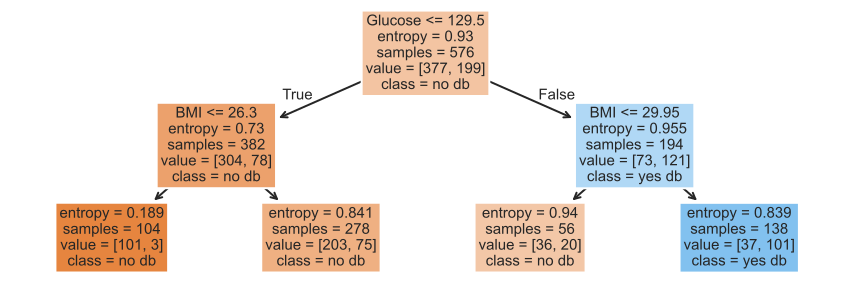

In [48]:
plt.figure(figsize=(15, 5))
plot_tree(dt, feature_names=X_train.columns, class_names=['no db', 'yes db'], 
          filled=True, fontsize=15, impurity=True);

We can recreate the entropy calculations above! Note that the default `DecisionTreeClassifier` uncertaintly metric _isn't_ entropy; it used entropy because we set `criterion='entropy'` when defining `dt`. (The default metric, [Gini impurity](https://en.wikipedia.org/wiki/Decision_tree_learning#:~:text=Gini%20impurity%20measures%20how%20often,into%20a%20single%20target%20category.), is perfectly fine too!)

In [49]:
# The first node at depth 2 has an entropy of 0.73,
# both told to us above and verified here!
entropy([0] * 304 + [1] * 78)

0.7302263747422792

### Tree depth

Decision trees are trained by **recursively** picking the best split until:

- all "leaf nodes" only contain training examples from a single class (good), or
- it is impossible to split leaf nodes any further (not good).

By default, there is no "maximum depth" for a decision tree. As such, without restriction, decision trees tend to be very deep.

In [50]:
dt_no_max = DecisionTreeClassifier()
dt_no_max.fit(X_train, y_train)

DecisionTreeClassifier()

A decision tree fit on our training data has a depth of around 20! (It is so deep that `tree.plot_tree` errors when trying to plot it.)

In [51]:
dt_no_max.tree_.max_depth

20

At first, this tree seems "better" than our tree of depth 2, since its training accuracy is much much higher:

In [52]:
dt_no_max.score(X_train, y_train)

0.9913194444444444

In [53]:
# Depth 2 tree.
dt.score(X_train, y_train)

0.765625

But recall, we truly care about **test set performance**, and this decision tree has **worse accuracy on the test set than our depth 2 tree**.

In [54]:
dt_no_max.score(X_test, y_test)

0.734375

In [55]:
# Depth 2 tree.
dt.score(X_test, y_test)

0.7760416666666666

### Decision trees and overfitting

- Decision trees have a tendency to overfit. **Why is that?**

- Unlike linear classification techniques (like logistic regression or SVMs), **decision trees are non-linear**.
    - They are also "non-parametric" – there are no $w^*$s to learn.

- While being trained, decision trees ask enough questions to effectively **memorize** the correct response values in the training set. However, the relationships they learn are often overfit to the noise in the training set, and don't generalize well.

In [56]:
fig

- A decision tree whose depth is not restricted will achieve 100% accuracy on any training set, as long as there are no "overlapping values" in the training set.
    - Two values overlap when they have the same features $x$ but different response values $y$ (e.g. if two patients have the same glucose levels and BMI, but one has diabetes and one doesn't).

- **One solution**: Make the decision tree "less complex" by limiting the maximum depth.

Since `sklearn.tree`'s `plot_tree` can't visualize extremely large decision trees, let's create and visualize some smaller decision trees.

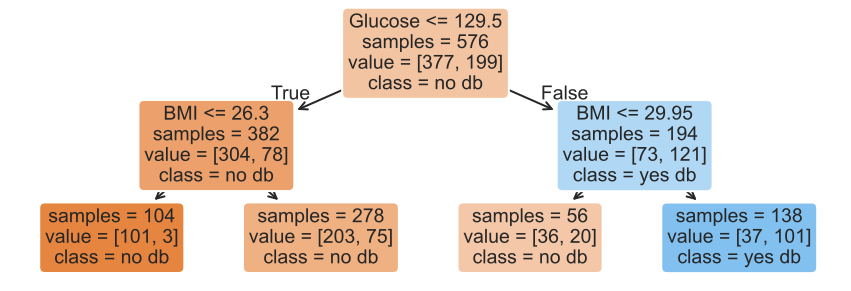

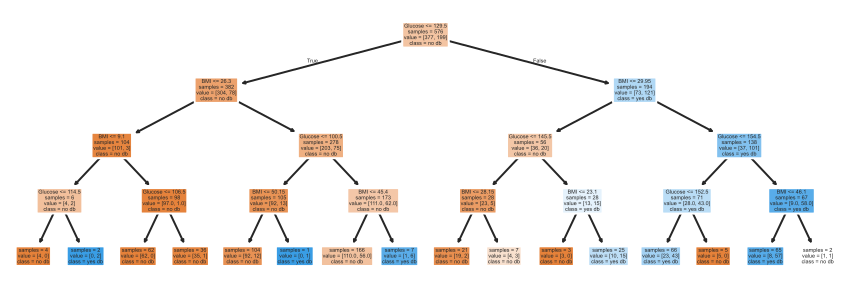

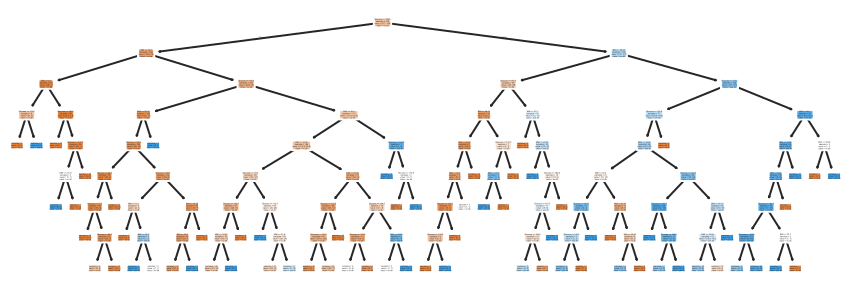

In [57]:
trees = {}
for d in [2, 4, 8]:
    trees[d] = DecisionTreeClassifier(max_depth=d, random_state=1)
    trees[d].fit(X_train, y_train)
    
    plt.figure(figsize=(15, 5), dpi=100)
    plot_tree(trees[d], feature_names=X_train.columns, class_names=['no db', 'yes db'], 
               filled=True, rounded=True, impurity=False)
    
    plt.show()

As tree depth increases, complexity increases, and our trees are more prone to overfitting. This means model bias decreases, but model variance increases. 

**Question**: What is the "right" maximum depth to choose?

### Hyperparameters for decision trees

- `max_depth` is a hyperparameter for `DecisionTreeClassifier`.

- There are many more hyperparameters we can tweak; look at [the documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) for examples.
    - `min_samples_split`: The minimum number of samples required to split an internal node.
    - `criterion`: The function to measure the quality of a split (`'gini'` or `'entropy'`).

- To ensure that our model generalizes well to unseen data, we need an efficient technique for trying different combinations of hyperparameters!

- We'll see that technique next time: `GridSearchCV`.

<div class="alert alert-warning">
    <h3>Question 🤔</h3>

</div>


(Fa23 Final 10.1)

Suppose we fit decision trees of varying depths to predict 'y' using 'x1' and 'x2'. The entire training set is shown in the table below.

<center><img src='https://practice.dsc80.com/assets/images/fa23-final/dsc_80_final_q10.png' width=15%></center>

What is:

1. The entropy of a node containing all the training points.
1. The lowest possible entropy of a node in a fitted tree with depth 1 (two leaf nodes).
1. The lowest possible entropy of a node in a fitted tree with depth 2 (four leaf nodes).

## Summary, next time

### Summary

- A hyperparameter is a configuration that we choose before training a model; an important task in machine learning is selecting "good" hyperparameters.
- To choose hyperparameters, we use $k$-fold cross-validation. **This technique is standard, and you are expected to use it in the Final Project!**
    - See [Summary: Generalization](#Summary:-Generalization) for more.
- Decision trees can be used for both regression and classification; we've used them for classification.
    - Decision trees are trained recursively. Each node corresponds to a "yes" or "no" question.
    - To decide which "yes" or "no" question to ask, we choose the question with the lowest weighted entropy.

### Next time

- An efficient technique for trying different combinations of hyperparameters.
    - In other words, performing $k$-fold cross-validation _without_ a `for`-loop.
- Techniques for evaluating classifiers beyond accuracy.
    - You'll need this for the Final Project!